# Ex2 Regression: Moore's Law (number of transistor per sqr inch X2 every two years)

In [1]:
#%pip install pandas

In [2]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## lets understand our data

In [3]:
df  = pd.read_csv('../DATA/moore.csv')

In [4]:
df.head()

,1971,2300
0,1972,3500
1,1973,2500
2,1973,2500
3,1974,4100
4,1974,4500


In [5]:
X,y = df.iloc[:,0].values,df.iloc[:,1].values

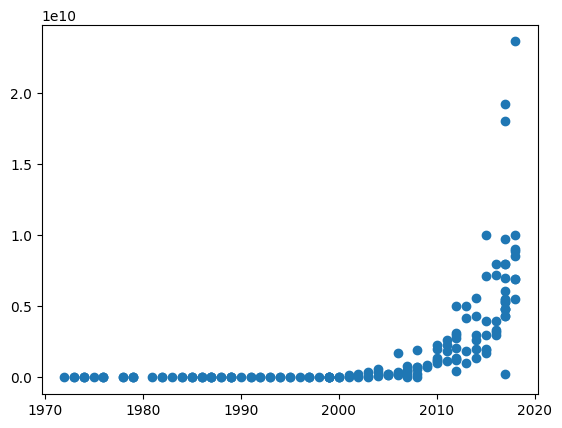

In [6]:
plt.scatter(X,y)

indeed moore law say the plot should be exponential, however if we take log it will be linear

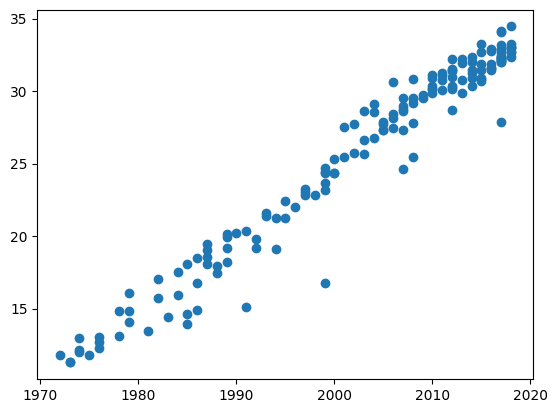

In [7]:
plt.scatter(X,np.log2(y))

now indeed a linear regression model can be used!

## transform the data

In [8]:
X = X.reshape(-1,1)
y = np.log2(y).reshape(-1,1)
print(f'X shape {X.shape} y shape {y.shape} ')
#normalize data
Xstd = X.std()
Xmean = X.mean()
ystd = y.std()
ymean= y.mean()

X= (X-Xmean)/Xstd
y = (y-ymean)/ystd

inputs = torch.from_numpy(X.astype(np.float32)).cuda()
targets = torch.from_numpy(y.astype(np.float32)).cuda()

X shape (161, 1) y shape (161, 1) 


## create the model

In [ ]:
model = nn.Linear(X.shape[1],y.shape[1]).cuda()
criterion = nn.MSELoss().cuda()
optimizer = opt.SGD(model.parameters(),lr=0.01,momentum=0.7)



## training 

In [10]:
EPOCHS = 90
losses = []

for epoch in range(EPOCHS): 
    model.zero_grad()

    predictions = model(inputs)
    loss = criterion(predictions,targets)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    print(f'{epoch+1}/{EPOCHS} loss: {loss.item()}')

1/90 loss: 0.9517629146575928
2/90 loss: 0.9156355857849121
3/90 loss: 0.880938708782196
4/90 loss: 0.8476158976554871
5/90 loss: 0.8156127333641052
6/90 loss: 0.7848769426345825
7/90 loss: 0.7553581595420837
8/90 loss: 0.7270084023475647
9/90 loss: 0.6997812986373901
10/90 loss: 0.6736322641372681
11/90 loss: 0.6485188007354736
12/90 loss: 0.6243999004364014
13/90 loss: 0.6012360453605652
14/90 loss: 0.5789896249771118
15/90 loss: 0.5576239824295044
16/90 loss: 0.5371044278144836
17/90 loss: 0.5173975229263306
18/90 loss: 0.4984709918498993
19/90 loss: 0.4802938997745514
20/90 loss: 0.4628366529941559
21/90 loss: 0.44607070088386536
22/90 loss: 0.4299687445163727
23/90 loss: 0.41450434923171997
24/90 loss: 0.3996523916721344
25/90 loss: 0.3853885233402252
26/90 loss: 0.3716895580291748
27/90 loss: 0.3585330843925476
28/90 loss: 0.3458975553512573
29/90 loss: 0.33376240730285645
30/90 loss: 0.32210785150527954
31/90 loss: 0.3109147846698761
32/90 loss: 0.30016493797302246
33/90 loss: 0

## plot losses

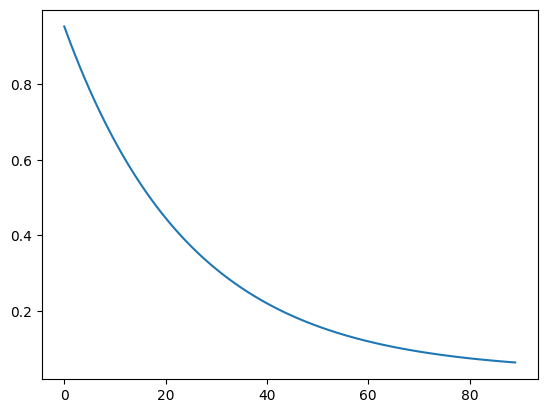

In [11]:
plt.plot(losses)

In [12]:
predictions =None
with torch.no_grad():
    predictions = model(inputs).cpu().numpy()

print(predictions)

[[-1.8343837 ]
 [-1.7712238 ]
 [-1.7712238 ]
 [-1.708064  ]
 [-1.708064  ]
 [-1.708064  ]
 [-1.644904  ]
 [-1.5817441 ]
 [-1.5817441 ]
 [-1.5817441 ]
 [-1.4554241 ]
 [-1.4554241 ]
 [-1.3922642 ]
 [-1.3922642 ]
 [-1.3922642 ]
 [-1.2659442 ]
 [-1.2027844 ]
 [-1.2027844 ]
 [-1.1396244 ]
 [-1.0764645 ]
 [-1.0764645 ]
 [-1.0133046 ]
 [-1.0133046 ]
 [-1.0133046 ]
 [-0.9501446 ]
 [-0.9501446 ]
 [-0.9501446 ]
 [-0.88698465]
 [-0.88698465]
 [-0.88698465]
 [-0.88698465]
 [-0.82382464]
 [-0.82382464]
 [-0.76066476]
 [-0.76066476]
 [-0.76066476]
 [-0.76066476]
 [-0.6975048 ]
 [-0.6343449 ]
 [-0.6343449 ]
 [-0.57118493]
 [-0.57118493]
 [-0.508025  ]
 [-0.508025  ]
 [-0.44486502]
 [-0.44486502]
 [-0.38170514]
 [-0.12906533]
 [-0.38170514]
 [-0.31854516]
 [-0.25538522]
 [-0.25538522]
 [-0.25538522]
 [-0.19222528]
 [-0.12906533]
 [-0.12906533]
 [-0.06590538]
 [-0.06590538]
 [-0.12906533]
 [-0.12906533]
 [-0.12906533]
 [-0.06590538]
 [-0.00274545]
 [-0.00274545]
 [ 0.06041449]
 [ 0.18673438]
 [ 0.18673

let's revert the normalization

In [13]:
X = X*Xstd+Xmean
y = y*ystd+ymean
predictions = predictions*ystd+ymean

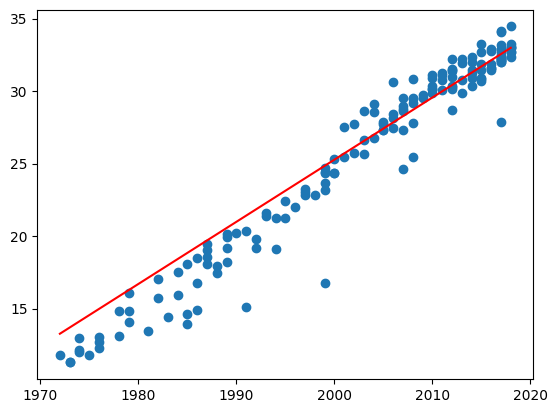

In [14]:
plt.scatter(X,y)
plt.plot(X,predictions,color='red')

[[2025]]
[[1.5130931]]
[[35.98773705]]


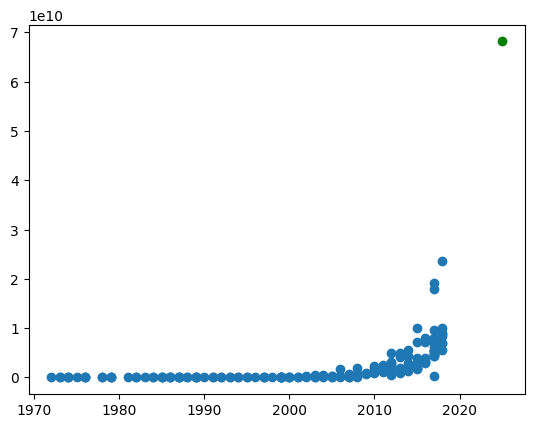

In [ ]:
#single point prediction
a = np.asarray([2025])
a = a.reshape(-1,1)
print(a)
a = (a-Xmean) / Xstd
singleinput = torch.from_numpy(a.astype(np.float32)).cuda()
with torch.no_grad():
    out = model(singleinput).cpu().numpy()
    out = out*ystd+ymean
    a = a*Xstd + Xmean
    plt.scatter(X,np.exp2(y))
    plt.scatter(a,np.exp2(out),color='green')